# Solving Kolmogorov's Backward Equation: Numerical Methods vs. Neural Networks

This notebook solves **Kolmogorov's backward equation** using two approaches:

1. **Numerical Methods** — FTCS (Explicit Finite Difference) and Crank–Nicolson (Implicit)
2. **Neural Network** — Physics-Informed Neural Network (PINN) via PyTorch

---

## Problem Statement

Given the stochastic process $dX_t = \mu\,dt + \sigma\,dW_t$ (Brownian motion with drift), Kolmogorov's backward equation governs the expected value $u(x, t) = \mathbb{E}[g(X_T) \mid X_t = x]$:

$$\frac{\partial u}{\partial t} + \mu\,\frac{\partial u}{\partial x} + \frac{\sigma^2}{2}\,\frac{\partial^2 u}{\partial x^2} = 0, \qquad x \in [-L, L],\; t \in [0, T]$$

This is a **linear, second-order parabolic PDE** (backward in time) with constant drift $\mu$ and diffusion coefficient $\sigma^2/2$.

**Terminal condition** — Gaussian payoff at $t = T$:

$$u(x, T) = g(x) = \exp\!\left(-\frac{x^2}{2\beta^2}\right), \quad \beta = 0.5$$

**Boundary conditions** — Dirichlet (the Gaussian decays to zero well within $[-L, L]$):

$$u(-L, t) = u(L, t) = 0$$

**Exact solution** — obtained by convolution with the transition kernel of the drift-diffusion process:

$$u^*(x, t) = \frac{\beta}{\sqrt{\beta^2 + \sigma^2(T - t)}}\;\exp\!\left(-\frac{\bigl(x + \mu(T - t)\bigr)^2}{2\bigl(\beta^2 + \sigma^2(T - t)\bigr)}\right)$$

As we go backward from $T$, the Gaussian **shifts** (by $\mu(T-t)$) and **broadens** (variance grows by $\sigma^2(T-t)$) — the uncertainty about the terminal value increases with the remaining time horizon.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.linalg import solve_banded
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
np.random.seed(42)
torch.manual_seed(42)

In [ ]:
CMAP = "inferno"

# ---- Problem parameters ---------------------
MU      = 0.5         # drift coefficient
SIGMA   = 0.3         # diffusion volatility  (D = σ² = 0.09)
D       = SIGMA**2    # diffusion coefficient
BETA    = 0.5         # terminal Gaussian width
L       = 5.0         # domain half-width
T_END   = 1.0         # time horizon

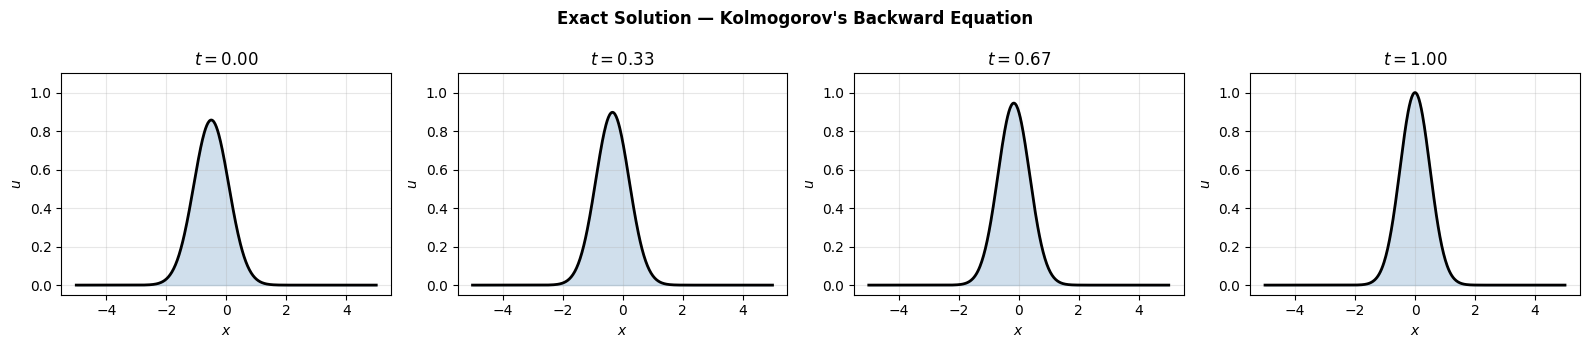

Drift μ = 0.5,  σ = 0.3,  D = σ² = 0.09
At t=0: amplitude ≈ 0.857, centre at x = -0.5, eff. width = 0.583


In [ ]:
def g_terminal(x):
    """Terminal condition g(x) = exp(-x²/(2β²))."""
    return np.exp(-x**2 / (2 * BETA**2))


def u_exact(x, t):
    """
    Exact solution of the backward Kolmogorov equation.
    u(x, t) = β / √(β² + σ²(T-t)) · exp(-(x + μ(T-t))² / (2(β² + σ²(T-t))))
    """
    tau = T_END - t
    var = BETA**2 + D * tau          # effective variance
    amp = BETA / np.sqrt(var)        # amplitude decay
    shift = x + MU * tau             # shifted centre
    return amp * np.exp(-shift**2 / (2 * var))


# Quick preview — exact solution at several times
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
x_plot = np.linspace(-L, L, 500)
for ax, t_snap in zip(axes, [0.0, 0.33, 0.67, 1.0]):
    ax.plot(x_plot, u_exact(x_plot, t_snap), "k-", lw=2)
    ax.fill_between(x_plot, u_exact(x_plot, t_snap), alpha=0.25, color="steelblue")
    ax.set_title(f"$t = {t_snap:.2f}$")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$u$")
    ax.set_ylim(-0.05, 1.1)
    ax.grid(alpha=0.3)

plt.suptitle("Exact Solution — Kolmogorov's Backward Equation", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Drift μ = {MU},  σ = {SIGMA},  D = σ² = {D}")
print(f"At t=0: amplitude ≈ {BETA / np.sqrt(BETA**2 + D * T_END):.3f}, "
      f"centre at x = {-MU * T_END:.1f}, "
      f"eff. width = {np.sqrt(BETA**2 + D * T_END):.3f}")

---

## Part 1 — Numerical Methods

We solve the equation **forward in the time-to-go variable** $\tau = T - t$.  Setting $v(x, \tau) = u(x, T - \tau)$ yields the advection–diffusion equation

$$\frac{\partial v}{\partial \tau} = \mu\,\frac{\partial v}{\partial x} + \frac{\sigma^2}{2}\,\frac{\partial^2 v}{\partial x^2}, \qquad v(x, 0) = g(x)$$

which is marched forward from $\tau = 0$ to $\tau = T$ using standard schemes.

### 1-A. FTCS — Forward Time, Central Space (Explicit)

Central differences for both advection and diffusion:

$$v_j^{n+1} = v_j^n + r\,\frac{v_{j+1}^n - v_{j-1}^n}{2} + s\left(v_{j+1}^n - 2v_j^n + v_{j-1}^n\right)$$

where

$$r = \frac{\mu\,\Delta\tau}{\Delta x}, \qquad s = \frac{\sigma^2\,\Delta\tau}{2\,\Delta x^2}$$

**Stability requirements**:
- Diffusion: $s \leq \tfrac{1}{2}$
- Advection (mesh Péclet number): $|\mu|\,\Delta x\,/\,\sigma^2 \leq 1$ to avoid spurious oscillations

In [ ]:
def solve_ftcs(Nx=200, Nt=400, T=T_END):
    """
    FTCS (explicit) for the advection-diffusion form of Kolmogorov's
    backward equation in τ = T − t.

    Parameters
    ----------
    Nx : int   Interior grid points.
    Nt : int   Number of time steps.

    Returns
    -------
    x      : ndarray (Nx+2,)   Grid including boundary points.
    v_hist : list of ndarray   Solution snapshots (in τ).
    t_hist : list of float     Corresponding t = T − τ values.
    """
    x   = np.linspace(-L, L, Nx + 2)   # includes boundaries
    dx  = x[1] - x[0]
    dt  = T / Nt

    r = MU * dt / dx
    s = D * dt / (2 * dx**2)

    # Stability check
    assert s <= 0.5, f"Diffusion CFL violated: s = {s:.4f} > 0.5"
    pe = abs(MU) * dx / D
    print(f"FTCS — dx={dx:.4f}, dτ={dt:.5f}, r={r:.4f}, s={s:.4f}, Pe_h={pe:.3f}")

    v       = g_terminal(x).copy()       # initial condition in τ
    v[0]    = v[-1] = 0.0                # Dirichlet BCs

    snap_steps = [0, Nt // 3, 2 * Nt // 3, Nt]
    v_hist, t_hist = [], []

    for n in range(Nt + 1):
        if n in snap_steps:
            tau_n = n * dt
            v_hist.append(v.copy())
            t_hist.append(T - tau_n)   # convert back to t
        if n == Nt:
            break

        v_new       = v.copy()
        # Vectorised interior update (j = 1 … Nx)
        v_new[1:-1] = (v[1:-1] + (r / 2) * (v[2:] - v[:-2]) + s * (v[2:] - 2 * v[1:-1] + v[:-2]))
        v_new[0]    = 0.0
        v_new[-1]   = 0.0
        v           = v_new

    return x, v_hist, t_hist


Nx_ftcs, Nt_ftcs                    = 200, 400
x_ftcs, v_ftcs_hist, t_ftcs_hist    = solve_ftcs(Nx_ftcs, Nt_ftcs)

# Error at earliest time (τ = T, i.e. t = 0)
u_ex_ftcs   = u_exact(x_ftcs, t_ftcs_hist[-1])
err_ftcs    = np.abs(v_ftcs_hist[-1] - u_ex_ftcs)
print(f"Max absolute error  : {err_ftcs.max():.3e}")
print(f"Mean absolute error : {err_ftcs.mean():.3e}")

FTCS — dx=0.0498, dτ=0.00250, r=0.0251, s=0.0455, Pe_h=0.276
Max absolute error  : 1.389e-03
Mean absolute error : 1.870e-04


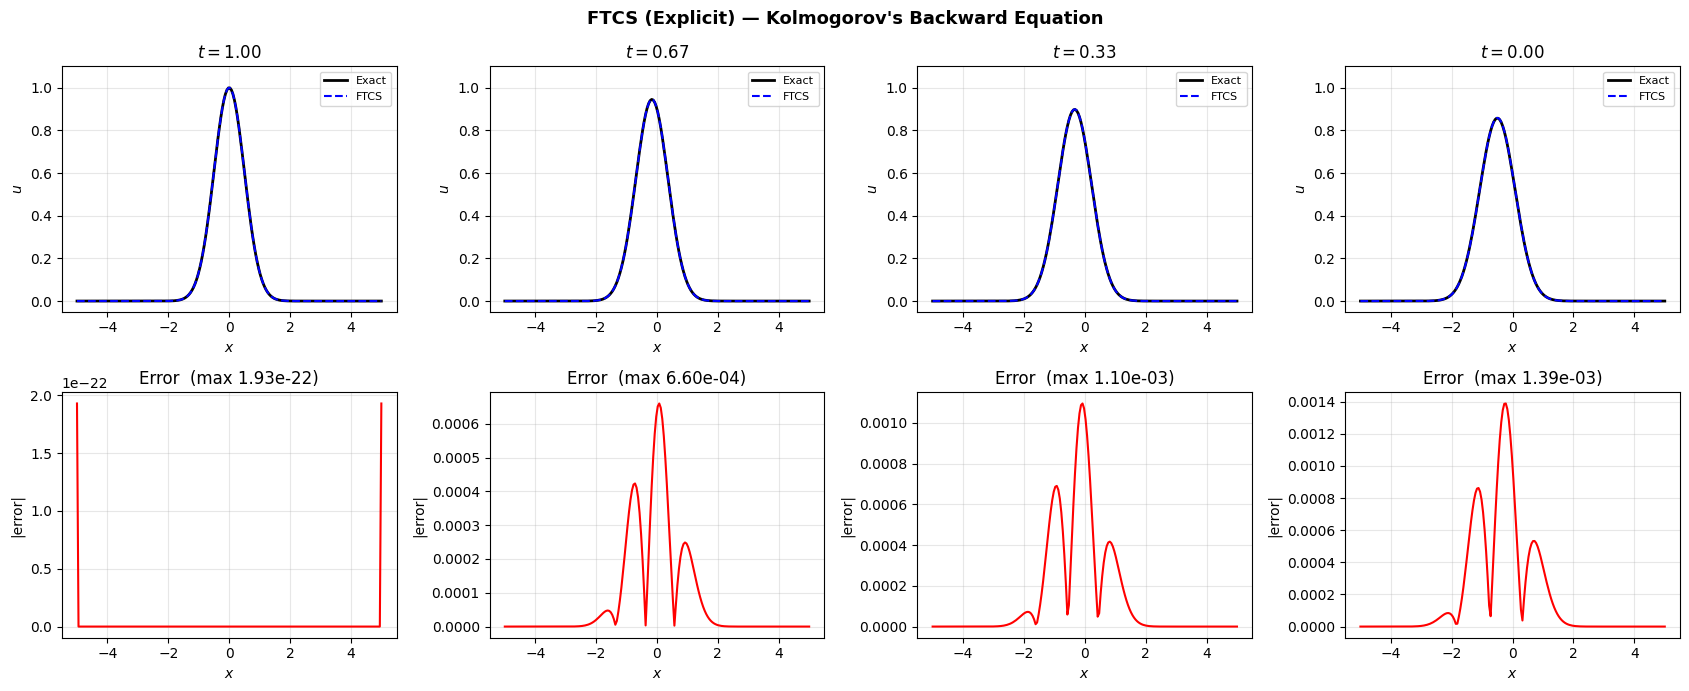

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for col, (v_snap, t_snap) in enumerate(zip(v_ftcs_hist, t_ftcs_hist)):
    u_ref = u_exact(x_ftcs, t_snap)

    axes[0, col].plot(x_ftcs, u_ref, "k-", lw=2, label="Exact")
    axes[0, col].plot(x_ftcs, v_snap, "b--", lw=1.5, label="FTCS")
    axes[0, col].set_title(f"$t = {t_snap:.2f}$")
    axes[0, col].set_xlabel("$x$")
    axes[0, col].set_ylabel("$u$")
    axes[0, col].legend(fontsize=8)
    axes[0, col].set_ylim(-0.05, 1.1)
    axes[0, col].grid(alpha=0.3)

    err = np.abs(v_snap - u_ref)
    axes[1, col].plot(x_ftcs, err, "r-", lw=1.5)
    axes[1, col].set_title(f"Error  (max {err.max():.2e})")
    axes[1, col].set_xlabel("$x$")
    axes[1, col].set_ylabel("|error|")
    axes[1, col].grid(alpha=0.3)

plt.suptitle("FTCS (Explicit) — Kolmogorov's Backward Equation",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 1-B. Crank–Nicolson (Implicit)

The Crank–Nicolson scheme averages the spatial operator at levels $n$ and $n+1$:

$$\left(I - \frac{\Delta\tau}{2}\mathcal{L}\right)\mathbf{v}^{n+1} = \left(I + \frac{\Delta\tau}{2}\mathcal{L}\right)\mathbf{v}^n$$

where

$$\mathcal{L}v_j = \mu\,\frac{v_{j+1} - v_{j-1}}{2\,\Delta x} + \frac{\sigma^2}{2}\,\frac{v_{j+1} - 2v_j + v_{j-1}}{\Delta x^2}$$

Defining the half-step weights

$$\alpha = \frac{\mu\,\Delta\tau}{4\,\Delta x}, \qquad \gamma = \frac{\sigma^2\,\Delta\tau}{4\,\Delta x^2}$$

the left-hand side is a **tridiagonal** system $A\,\mathbf{v}^{n+1} = B\,\mathbf{v}^n$:

| Band | $A$ (LHS) | $B$ (RHS) |
|------|-----------|----------|
| sub-diagonal | $\alpha - \gamma$ | $-\alpha + \gamma$ |
| diagonal | $1 + 2\gamma$ | $1 - 2\gamma$ |
| super-diagonal | $-\alpha - \gamma$ | $\alpha + \gamma$ |

Crank–Nicolson is **unconditionally stable** and $\mathcal{O}(\Delta\tau^2,\,\Delta x^2)$.

In [ ]:
def solve_crank_nicolson(Nx=200, Nt=100, T=T_END):
    """
    Crank–Nicolson for the advection-diffusion form of Kolmogorov's
    backward equation in τ = T − t.

    Parameters
    ----------
    Nx : int   Interior grid points.
    Nt : int   Number of time steps.

    Returns
    -------
    x      : ndarray (Nx+2,)
    v_hist : list of ndarray
    t_hist : list of float     (in original t = T − τ)
    """
    x   = np.linspace(-L, L, Nx + 2)
    dx  = x[1] - x[0]
    dt  = T / Nt

    alpha = MU * dt / (4 * dx)
    gamma = D * dt / (4 * dx**2)
    print(f"Crank–Nicolson — dx={dx:.4f}, dτ={dt:.5f}, α={alpha:.5f}, γ={gamma:.5f}")

    N = Nx  # number of interior points

    # Build banded matrices (interior points only: indices 1..Nx)
    # A (LHS): (α − γ) sub, (1+2γ) diag, (−α − γ) super
    # B (RHS): (−α + γ) sub, (1−2γ) diag, (α + γ) super
    # scipy solve_banded needs (l, u) banded storage
    A_band          = np.zeros((3, N))   # rows: super, diag, sub
    A_band[0, 1:]   = -alpha - gamma     # super-diagonal
    A_band[1, :]    = 1 + 2 * gamma      # diagonal
    A_band[2, :-1]  = alpha - gamma      # sub-diagonal

    # RHS multiplier (dense tridiag multiply)
    b_sub   = -alpha + gamma
    b_diag  = 1 - 2 * gamma
    b_sup   = alpha + gamma

    def rhs_multiply(v_int):
        """Multiply interior vector by RHS tridiagonal matrix B."""
        r       = b_diag * v_int.copy()
        r[:-1]  += b_sup * v_int[1:]
        r[1:]   += b_sub * v_int[:-1]
        return r

    v = g_terminal(x).copy()
    v[0] = v[-1] = 0.0

    snap_steps = [0, Nt // 3, 2 * Nt // 3, Nt]
    v_hist, t_hist = [], []

    for n in range(Nt + 1):
        if n in snap_steps:
            tau_n = n * dt
            v_hist.append(v.copy())
            t_hist.append(T - tau_n)
        if n == Nt:
            break

        rhs     = rhs_multiply(v[1:-1])
        v[1:-1] = solve_banded((1, 1), A_band, rhs)
        v[0]    = 0.0
        v[-1]   = 0.0

    return x, v_hist, t_hist


Nx_cn, Nt_cn = 200, 100
x_cn, v_cn_hist, t_cn_hist = solve_crank_nicolson(Nx_cn, Nt_cn)

u_ex_cn = u_exact(x_cn, t_cn_hist[-1])
err_cn = np.abs(v_cn_hist[-1] - u_ex_cn)
print(f"Max absolute error  : {err_cn.max():.3e}")
print(f"Mean absolute error : {err_cn.mean():.3e}")

Crank–Nicolson — dx=0.0498, dτ=0.01000, α=0.02513, γ=0.09090
Max absolute error  : 1.252e-03
Mean absolute error : 1.985e-04


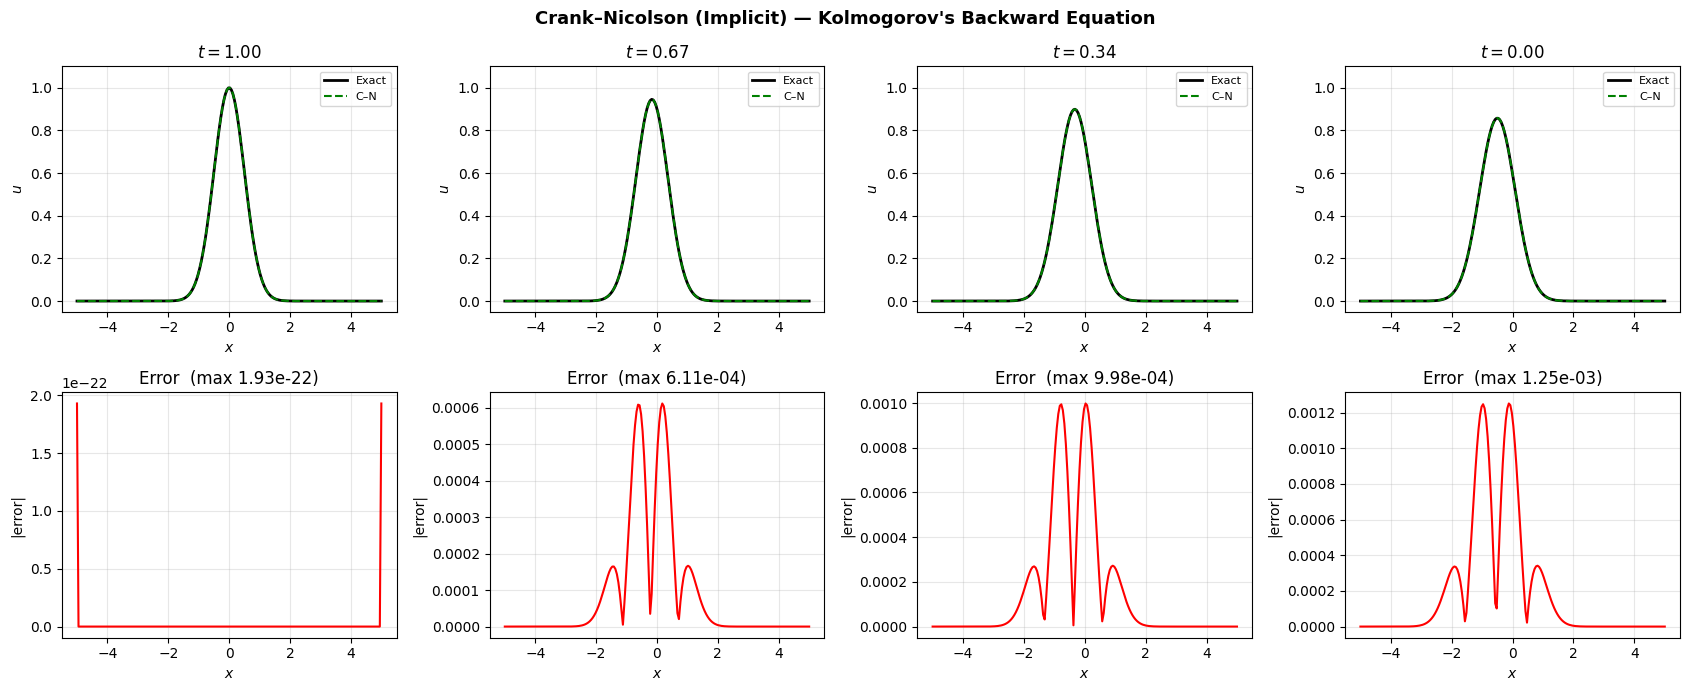

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for col, (v_snap, t_snap) in enumerate(zip(v_cn_hist, t_cn_hist)):
    u_ref = u_exact(x_cn, t_snap)

    axes[0, col].plot(x_cn, u_ref, "k-", lw=2, label="Exact")
    axes[0, col].plot(x_cn, v_snap, "g--", lw=1.5, label="C–N")
    axes[0, col].set_title(f"$t = {t_snap:.2f}$")
    axes[0, col].set_xlabel("$x$")
    axes[0, col].set_ylabel("$u$")
    axes[0, col].legend(fontsize=8)
    axes[0, col].set_ylim(-0.05, 1.1)
    axes[0, col].grid(alpha=0.3)

    err = np.abs(v_snap - u_ref)
    axes[1, col].plot(x_cn, err, "r-", lw=1.5)
    axes[1, col].set_title(f"Error  (max {err.max():.2e})")
    axes[1, col].set_xlabel("$x$")
    axes[1, col].set_ylabel("|error|")
    axes[1, col].grid(alpha=0.3)

plt.suptitle("Crank–Nicolson (Implicit) — Kolmogorov's Backward Equation",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

FTCS — dx=0.3846, dτ=0.00500, r=0.0065, s=0.0015, Pe_h=2.137
Crank–Nicolson — dx=0.3846, dτ=0.00500, α=0.00162, γ=0.00076
FTCS — dx=0.1961, dτ=0.00500, r=0.0127, s=0.0059, Pe_h=1.089
Crank–Nicolson — dx=0.1961, dτ=0.00500, α=0.00319, γ=0.00293
FTCS — dx=0.0990, dτ=0.00500, r=0.0252, s=0.0230, Pe_h=0.550
Crank–Nicolson — dx=0.0990, dτ=0.00500, α=0.00631, γ=0.01148
FTCS — dx=0.0498, dτ=0.00500, r=0.0503, s=0.0909, Pe_h=0.276
Crank–Nicolson — dx=0.0498, dτ=0.00500, α=0.01256, γ=0.04545
FTCS — dx=0.0249, dτ=0.00500, r=0.1003, s=0.3618, Pe_h=0.139
Crank–Nicolson — dx=0.0249, dτ=0.00500, α=0.02506, γ=0.18090


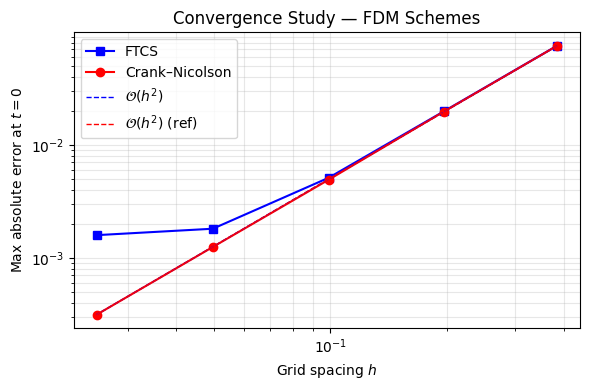

In [ ]:
# ---- Grid-refinement convergence study ----------------------------------------
Nx_list = [25, 50, 100, 200, 400]
err_ftcs_conv, err_cn_conv = [], []

for Nx in Nx_list:
    # FTCS needs enough time steps for stability
    dx_c            = 2 * L / (Nx + 1)
    Nt_c            = max(int(np.ceil(T_END * D / (dx_c**2))), 200)
    x_c, v_c, t_c   = solve_ftcs(Nx, Nt_c)
    u_ex_c          = u_exact(x_c, t_c[-1])
    err_ftcs_conv.append(np.max(np.abs(v_c[-1] - u_ex_c)))

    # Crank–Nicolson — fixed moderate Nt
    x_c2, v_c2, t_c2    = solve_crank_nicolson(Nx, Nt=200)
    u_ex_c2             = u_exact(x_c2, t_c2[-1])
    err_cn_conv.append(np.max(np.abs(v_c2[-1] - u_ex_c2)))

dh = [2 * L / (Nx + 1) for Nx in Nx_list]

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(dh, err_ftcs_conv, "bs-", lw=1.5, label="FTCS")
ax.loglog(dh, err_cn_conv,   "ro-", lw=1.5, label="Crank–Nicolson")
ax.loglog(dh, [h**2 * err_ftcs_conv[0] / dh[0]**2 for h in dh], "b--", lw=1.0, label="$\\mathcal{O}(h^2)$")
ax.loglog(dh, [h**2 * err_cn_conv[0] / dh[0]**2 for h in dh], "r--", lw=1.0, label="$\\mathcal{O}(h^2)$ (ref)")
ax.set_xlabel("Grid spacing $h$")
ax.set_ylabel("Max absolute error at $t = 0$")
ax.set_title("Convergence Study — FDM Schemes")
ax.legend()
ax.grid(which="both", alpha=0.3)
plt.tight_layout()
plt.show()

---

## Part 2 — Neural Network: Physics-Informed Neural Network (PINN)

### How It Works

A PINN learns $\hat{u}_\theta(x, t)$ by minimising:

$$\mathcal{L} = \underbrace{\mathcal{L}_{TC}}_{\text{terminal condition}} + \underbrace{\mathcal{L}_{BC}}_{\text{boundary}} + \underbrace{\mathcal{L}_{PDE}}_{\text{physics residual}}$$

$$\mathcal{L}_{TC} = \frac{1}{N_{TC}}\sum_k \Bigl(\hat{u}(x_k, T) - g(x_k)\Bigr)^2$$

$$\mathcal{L}_{BC} = \frac{1}{N_{BC}}\sum_k \left[\hat{u}(-L, t_k)^2 + \hat{u}(L, t_k)^2\right]$$

$$\mathcal{L}_{PDE} = \frac{1}{N_f}\sum_k \left(\frac{\partial\hat{u}}{\partial t} + \mu\,\frac{\partial\hat{u}}{\partial x} + \frac{\sigma^2}{2}\,\frac{\partial^2\hat{u}}{\partial x^2}\right)^2$$

The **second derivative** $u_{xx}$ is computed via two successive calls to `torch.autograd.grad`.

**Sampling strategy** — the Gaussian has support only near $x = 0$ at $t = T$ and near $x \approx -\mu T$ at $t = 0$. We therefore combine:
- **Uniform** samples over the full $(x, t)$ domain
- **Focused** terminal-condition points near the Gaussian peak

Training: **Adam** warm-up → **L-BFGS** fine-tuning.

In [ ]:
# -----------------------------------------------------------------
# Network Architecture
# -----------------------------------------------------------------
class KolmogorovPINN(nn.Module):
    """Fully-connected PINN: (x, t) → u.
    Tanh activations ensure smooth second-order derivatives via autograd.
    """

    def __init__(self, hidden_layers=5, hidden_dim=80):
        super().__init__()
        layers = [nn.Linear(2, hidden_dim), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))


def grad1(u, v):
    return torch.autograd.grad(
        u, v, grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]


# -----------------------------------------------------------------
# Collocation / TC / BC Points
# -----------------------------------------------------------------
N_TC_UNIF   = 2000    # uniform terminal-condition points
N_TC_FOCUS  = 1500    # focused near Gaussian peak at t = T
N_BC        = 1000    # boundary points (each side)
N_INT       = 10000   # interior PDE collocation points

# ---- Uniform TC at t = T --------------------------
x_tc_u = (torch.rand(N_TC_UNIF, 1) * 2 * L - L)
t_tc_u = torch.full((N_TC_UNIF, 1), T_END)
u_tc_u = torch.tensor(
    g_terminal(x_tc_u.numpy()), dtype=torch.float32
)

# ---- Focused TC near Gaussian peak ----------------
x_tc_f = torch.randn(N_TC_FOCUS, 1) * BETA
x_tc_f = x_tc_f.clamp(-L, L)
t_tc_f = torch.full((N_TC_FOCUS, 1), T_END)
u_tc_f = torch.tensor(
    g_terminal(x_tc_f.numpy()), dtype=torch.float32
)

# ---- Merge TC sets --------------------------------
x_tc = torch.cat([x_tc_u, x_tc_f])
t_tc = torch.cat([t_tc_u, t_tc_f])
u_tc = torch.cat([u_tc_u, u_tc_f])

# ---- Boundary points (x = ±L) --------------------
t_bc = torch.rand(N_BC, 1) * T_END
x_bc_left = torch.full((N_BC, 1), -L)
x_bc_right = torch.full((N_BC, 1),  L)

# ---- Interior PDE collocation points --------------
x_int = (torch.rand(N_INT, 1) * 2 * L - L).requires_grad_(True)
t_int = (torch.rand(N_INT, 1) * T_END).requires_grad_(True)

mse = nn.MSELoss()

print(f"TC  points : {len(x_tc)}")
print(f"BC  points : {2 * N_BC}")
print(f"PDE points : {N_INT}")

TC  points : 3500
BC  points : 2000
PDE points : 10000


In [ ]:
def compute_loss(model):
    # ---- Terminal-condition loss ------
    u_pred_tc   = model(x_tc, t_tc)
    loss_tc     = mse(u_pred_tc, u_tc)

    # ---- Boundary loss (u = 0 at x = ±L) -----
    u_left  = model(x_bc_left,  t_bc)
    u_right = model(x_bc_right, t_bc)
    loss_bc = mse(u_left,  torch.zeros_like(u_left)) + mse(u_right, torch.zeros_like(u_right))

    # ---- PDE residual: u_t + μ·u_x + (σ²/2)·u_xx = 0 -----
    u_pred      = model(x_int, t_int)
    u_t         = grad1(u_pred, t_int)
    u_x         = grad1(u_pred, x_int)
    u_xx        = grad1(u_x,    x_int)
    residual    = u_t + MU * u_x + (D / 2) * u_xx
    loss_pde    = mse(residual, torch.zeros_like(residual))

    return loss_tc + loss_bc + loss_pde, loss_tc, loss_bc, loss_pde


# ---- Phase 1: Adam --------------------------------
model = KolmogorovPINN(hidden_layers=5, hidden_dim=80)
opt_adam = optim.Adam(model.parameters(), lr=1e-3)
ADAM_EP = 5000
history = []

for ep in range(1, ADAM_EP + 1):
    opt_adam.zero_grad()
    loss, l_tc, l_bc, l_pde = compute_loss(model)
    loss.backward()
    opt_adam.step()
    history.append(loss.item())
    if ep % 1000 == 0:
        print(f"[Adam] Ep {ep:5d} | Loss {loss.item():.5f} | "
              f"TC {l_tc.item():.5f} | BC {l_bc.item():.5f} | PDE {l_pde.item():.5f}")
print("Adam phase done.")

[Adam] Ep  1000 | Loss 0.00005 | TC 0.00002 | BC 0.00000 | PDE 0.00003
[Adam] Ep  2000 | Loss 0.00002 | TC 0.00001 | BC 0.00000 | PDE 0.00001
[Adam] Ep  3000 | Loss 0.00001 | TC 0.00000 | BC 0.00000 | PDE 0.00001
[Adam] Ep  4000 | Loss 0.00001 | TC 0.00000 | BC 0.00000 | PDE 0.00000
[Adam] Ep  5000 | Loss 0.00000 | TC 0.00000 | BC 0.00000 | PDE 0.00000
Adam phase done.


L-BFGS done.  Final loss: 0.000000


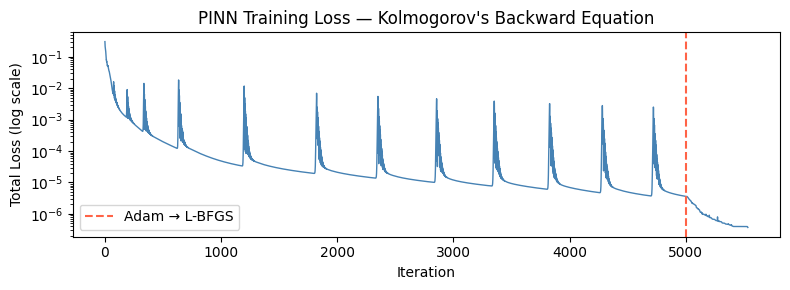

In [12]:
# ---- Phase 2: L-BFGS ----
opt_lbfgs = optim.LBFGS(
    model.parameters(),
    max_iter=500, tolerance_grad=1e-9, tolerance_change=1e-12,
    history_size=50, line_search_fn="strong_wolfe"
)

def closure():
    opt_lbfgs.zero_grad()
    loss, _, _, _ = compute_loss(model)
    loss.backward()
    history.append(loss.item())
    return loss


opt_lbfgs.step(closure)
final, _, _, _ = compute_loss(model)
print(f"L-BFGS done.  Final loss: {final.item():.6f}")

# Training loss curve
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(history, color="steelblue", lw=1.0)
ax.axvline(x=ADAM_EP, color="tomato", ls="--", lw=1.5, label="Adam → L-BFGS")
ax.set_xlabel("Iteration")
ax.set_ylabel("Total Loss (log scale)")
ax.set_title("PINN Training Loss — Kolmogorov's Backward Equation")
ax.legend()
plt.tight_layout()
plt.show()

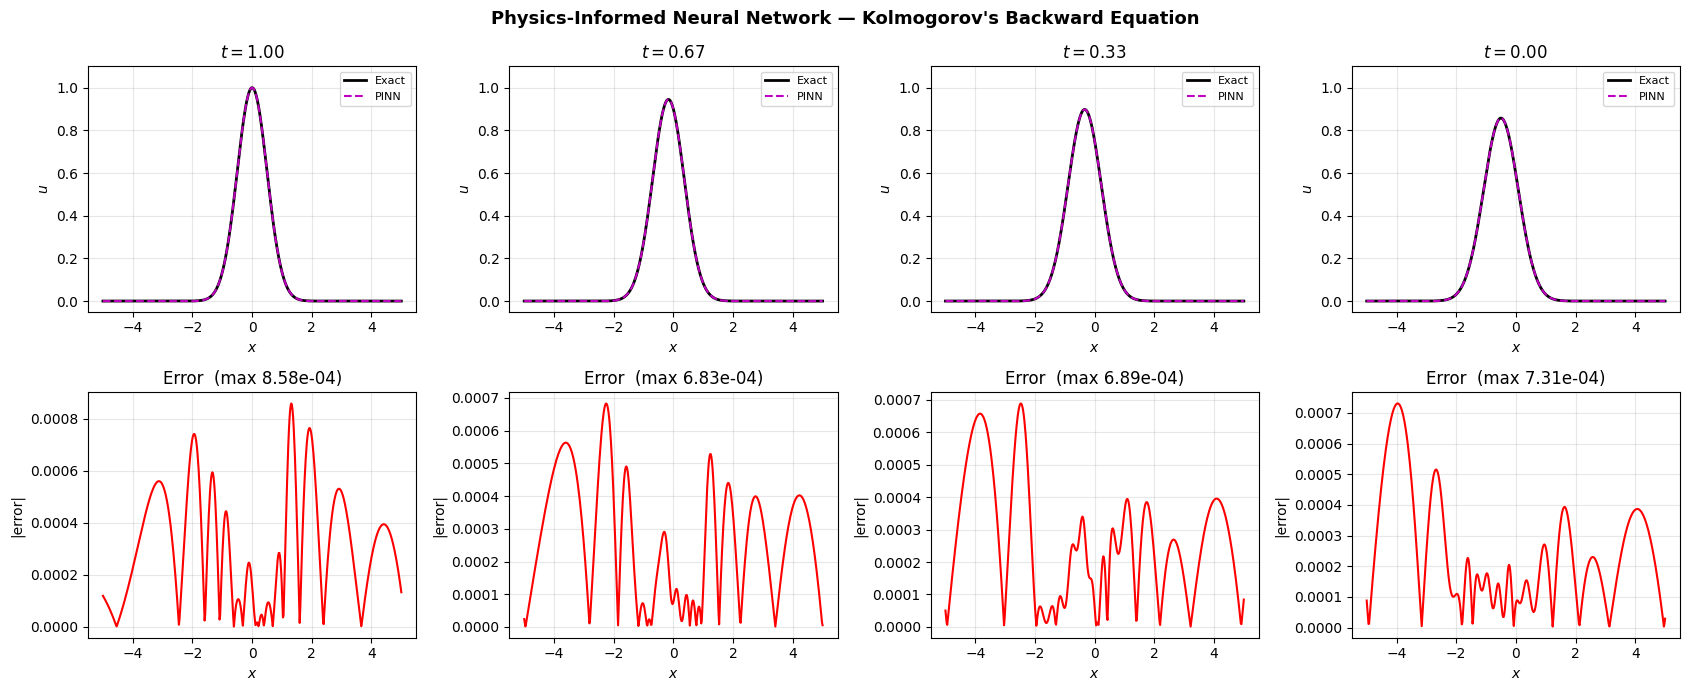

PINN — Max error at t=0: 7.31e-04  |  Mean error: 2.41e-04


In [13]:
# ---- Evaluate PINN on a dense x grid at each snapshot time ----
model.eval()
Nev = 500
x_ev = np.linspace(-L, L, Nev)


def pinn_predict(t_val):
    xt = torch.tensor(x_ev, dtype=torch.float32).unsqueeze(1)
    tt = torch.full((Nev, 1), t_val, dtype=torch.float32)
    with torch.no_grad():
        return model(xt, tt).numpy().ravel()


snap_times_pinn = [1.0, 2 * T_END / 3, T_END / 3, 0.0]
U_pinn_snaps    = [pinn_predict(t) for t in snap_times_pinn]

# PINN error at t = 0
U_ex_pinn   = u_exact(x_ev, 0.0)
err_pinn    = np.abs(U_pinn_snaps[-1] - U_ex_pinn)

fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for col, (U_snap, t_snap) in enumerate(zip(U_pinn_snaps, snap_times_pinn)):
    u_ref = u_exact(x_ev, t_snap)

    axes[0, col].plot(x_ev, u_ref, "k-", lw=2, label="Exact")
    axes[0, col].plot(x_ev, U_snap, "m--", lw=1.5, label="PINN")
    axes[0, col].set_title(f"$t = {t_snap:.2f}$")
    axes[0, col].set_xlabel("$x$")
    axes[0, col].set_ylabel("$u$")
    axes[0, col].legend(fontsize=8)
    axes[0, col].set_ylim(-0.05, 1.1)
    axes[0, col].grid(alpha=0.3)

    err = np.abs(U_snap - u_ref)
    axes[1, col].plot(x_ev, err, "r-", lw=1.5)
    axes[1, col].set_title(f"Error  (max {err.max():.2e})")
    axes[1, col].set_xlabel("$x$")
    axes[1, col].set_ylabel("|error|")
    axes[1, col].grid(alpha=0.3)

plt.suptitle("Physics-Informed Neural Network — Kolmogorov's Backward Equation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"PINN — Max error at t=0: {err_pinn.max():.2e}  |  Mean error: {err_pinn.mean():.2e}")

---

## Part 3 — Side-by-Side Comparison

Solutions from all three methods at $t = 0$ (the furthest backward time) alongside the exact solution, plus a quantitative error summary.

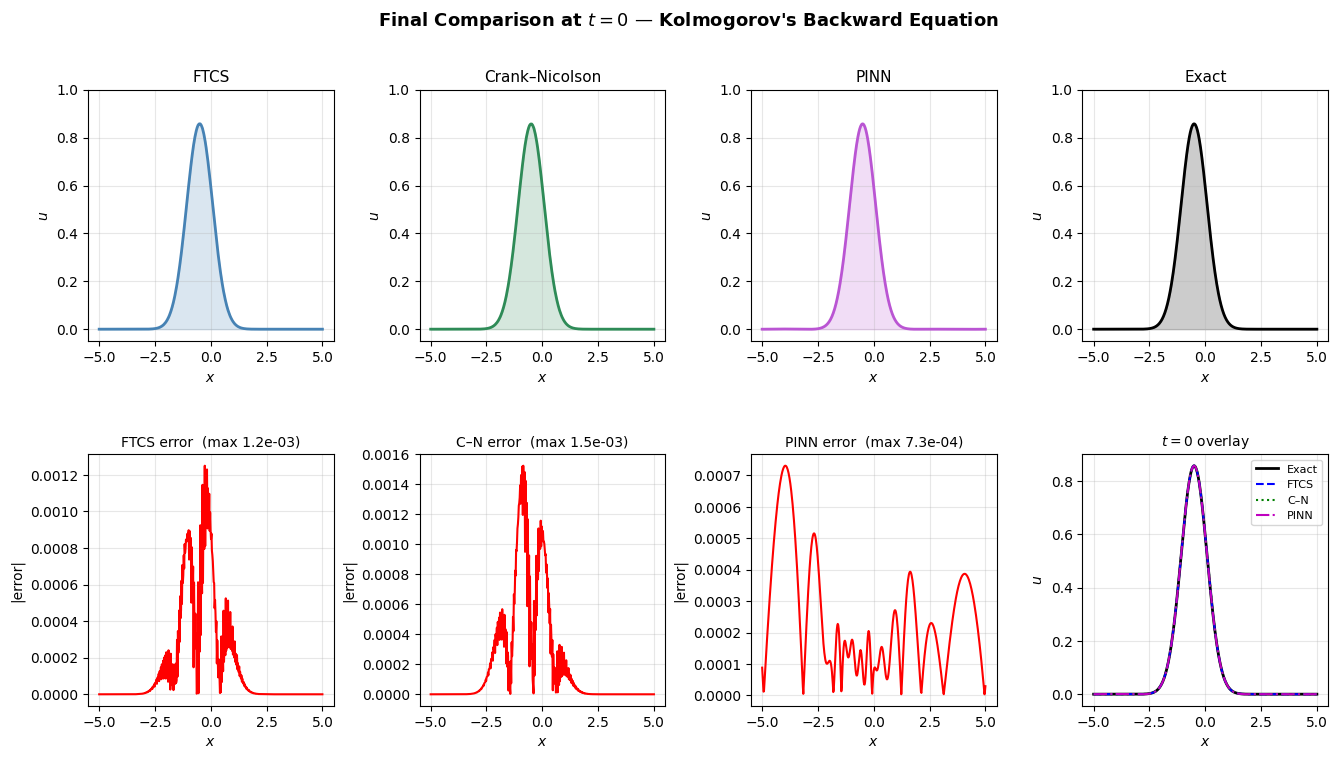

In [ ]:
# Interpolate FD solutions onto the common evaluation grid
from scipy.interpolate import interp1d

u_ftcs_ev   = interp1d(x_ftcs, v_ftcs_hist[-1], kind="linear", bounds_error=False, fill_value=0.0)(x_ev)
u_cn_ev     = interp1d(x_cn,   v_cn_hist[-1],   kind="linear", bounds_error=False, fill_value=0.0)(x_ev)
u_pinn_ev   = U_pinn_snaps[-1]

err_ftcs_ev = np.abs(u_ftcs_ev - U_ex_pinn)
err_cn_ev   = np.abs(u_cn_ev - U_ex_pinn)
err_pinn_ev = np.abs(u_pinn_ev - U_ex_pinn)

fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

labels  = ["FTCS", "Crank–Nicolson", "PINN", "Exact"]
sols    = [u_ftcs_ev, u_cn_ev, u_pinn_ev, U_ex_pinn]
colors  = ["steelblue", "seagreen", "mediumorchid", "black"]
errs    = [err_ftcs_ev, err_cn_ev, err_pinn_ev]
e_lbl   = ["FTCS error", "C–N error", "PINN error"]

for col, (lbl, sol, c) in enumerate(zip(labels, sols, colors)):
    ax = fig.add_subplot(gs[0, col])
    ax.plot(x_ev, sol, color=c, lw=2)
    ax.fill_between(x_ev, sol, alpha=0.2, color=c)
    ax.set_title(lbl, fontsize=11)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$u$")
    ax.set_ylim(-0.05, 1.0)
    ax.grid(alpha=0.3)

for col, (lbl, err) in enumerate(zip(e_lbl, errs)):
    ax = fig.add_subplot(gs[1, col])
    ax.plot(x_ev, err, "r-", lw=1.5)
    ax.set_title(f"{lbl}  (max {err.max():.1e})", fontsize=10)
    ax.set_xlabel("$x$")
    ax.set_ylabel("|error|")
    ax.grid(alpha=0.3)

# Overlay plot for direct comparison
ax_ov = fig.add_subplot(gs[1, 3])
ax_ov.plot(x_ev, U_ex_pinn,  "k-",  lw=2,   label="Exact")
ax_ov.plot(x_ev, u_ftcs_ev,  "b--", lw=1.5, label="FTCS")
ax_ov.plot(x_ev, u_cn_ev,    "g:",  lw=1.5, label="C–N")
ax_ov.plot(x_ev, u_pinn_ev,  "m-.", lw=1.5, label="PINN")
ax_ov.set_title("$t = 0$ overlay", fontsize=10)
ax_ov.set_xlabel("$x$")
ax_ov.set_ylabel("$u$")
ax_ov.legend(fontsize=8)
ax_ov.grid(alpha=0.3)

fig.suptitle(f"Final Comparison at $t = 0$ — Kolmogorov's Backward Equation", fontsize=13, fontweight="bold")
plt.show()

In [ ]:
# ---- Quantitative error summary ---------------------------------------------------
def l2_norm(f_arr, x_arr):
    return np.sqrt(np.trapezoid(f_arr**2, x_arr))

I_exact_T  = np.trapezoid(u_exact(x_ev, T_END), x_ev)
I_exact_0  = np.trapezoid(U_ex_pinn, x_ev)
I_ftcs     = np.trapezoid(u_ftcs_ev, x_ev)
I_cn       = np.trapezoid(u_cn_ev, x_ev)
I_pinn     = np.trapezoid(u_pinn_ev, x_ev)

print("=" * 70)
print(f"{'Method':<22} {'Max error':>12} {'Mean error':>12} {'L² error':>12} {'∫u dx':>10}")
print("-" * 70)
print(f"{'Exact (t=T)':22} {'—':>12} {'—':>12} {'—':>12} {I_exact_T:>10.4f}")
print(f"{'Exact (t=0)':22} {'—':>12} {'—':>12} {'—':>12} {I_exact_0:>10.4f}")
print(f"{'FTCS':22} {err_ftcs_ev.max():>12.3e} {err_ftcs_ev.mean():>12.3e} "
      f"{l2_norm(err_ftcs_ev, x_ev):>12.3e} {I_ftcs:>10.4f}")
print(f"{'Crank–Nicolson':22} {err_cn_ev.max():>12.3e} {err_cn_ev.mean():>12.3e} "
      f"{l2_norm(err_cn_ev, x_ev):>12.3e} {I_cn:>10.4f}")
print(f"{'PINN':22} {err_pinn_ev.max():>12.3e} {err_pinn_ev.mean():>12.3e} "
      f"{l2_norm(err_pinn_ev, x_ev):>12.3e} {I_pinn:>10.4f}")
print("=" * 70)

Method                    Max error   Mean error     L² error      ∫u dx
----------------------------------------------------------------------
Exact (t=T)                       —            —            —     1.2533
Exact (t=0)                       —            —            —     1.2533
FTCS                      1.249e-03    1.550e-04    9.915e-04     1.2533
Crank–Nicolson            1.524e-03    2.026e-04    1.297e-03     1.2533
PINN                      7.307e-04    2.409e-04    9.541e-04     1.2533


---

## Summary

### About Kolmogorov's Backward Equation

Kolmogorov's backward equation is a cornerstone of stochastic analysis and mathematical finance. Key properties:

- It is a **linear, second-order parabolic PDE** — a time-reversed advection–diffusion equation whose coefficients are determined by the drift and volatility of the underlying stochastic process.
- The solution $u(x, t) = \mathbb{E}[g(X_T) \mid X_t = x]$ gives the **conditional expectation** of a terminal payoff $g$. In finance this is the price of a derivative; in physics it is the expected observable at a future time.
- For constant drift $\mu$ and volatility $\sigma$ the exact solution is a **shifting and broadening Gaussian** — an ideal test problem with a closed-form reference.

### Method Comparison

| Aspect | FTCS (Explicit) | Crank–Nicolson (Implicit) | PINN |
|--------|----------------|--------------------------|------|
| **Core idea** | Forward Euler + central differences | Trapezoidal rule + central differences | Minimise PDE + TC + BC residuals |
| **Accuracy** | $\mathcal{O}(\Delta t,\,h^2)$ | $\mathcal{O}(\Delta t^2,\,h^2)$ | Depends on training |
| **Stability** | Conditional ($s \leq 1/2$) | Unconditional | Unconditional |
| **Artefact** | Diffusion & possible oscillations | Minimal numerical diffusion | None by design |
| **Linear system** | None (explicit) | Tridiagonal solve per step | None (gradient descent) |
| **Mesh required** | Yes — uniform 1D grid | Yes — uniform 1D grid | No — meshfree |
| **Best for** | Quick prototyping, small problems | Production-grade 1D parabolic PDEs | High-dimensional or parametric problems |

### Key Observations

- **FTCS** is the simplest scheme but is limited by a strict stability constraint that forces many small time steps.  It is first-order in time, so accuracy lags behind Crank–Nicolson for the same spatial resolution.
- **Crank–Nicolson** is second-order in both space and time and unconditionally stable, making it the standard workhorse for 1-D parabolic problems.  The cost per step is one tridiagonal solve — negligible.
- The **PINN** requires no mesh and no time-stepping, but training a network to capture the second derivative accurately is more challenging than for first-order PDEs.  Careful sampling near the Gaussian support and sufficient network capacity are needed to achieve competitive accuracy.